# **Fake Text Detection with steering vectors**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install --no-deps bitsandbytes accelerate xformers peft trl triton cut_cross_entropy unsloth_zoo
!pip install sentencepiece protobuf "datasets>=3.4.1,<4.0.0" "huggingface_hub>=0.34.0" hf_transfer
!pip install --no-deps unsloth
!pip install --no-deps trl==0.22.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.7/564.7 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.7/247.7 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 13.1 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2025.9.12 requires msgspec, which is not installed.
unsloth-zoo 2025.9.12 requires tyro, which is not installed.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB

In [ ]:
!pip install -Uq steering-vectors

In [ ]:
# !pip install raid-bench

In [ ]:
import unsloth
from unsloth import FastLanguageModel
import pandas as pd
import numpy as np
import torch
from torch.nn import functional as F
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from datasets import load_dataset, load_from_disk, concatenate_datasets, DatasetDict, Dataset
from steering_vectors import record_activations, SteeringVector
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from collections import Counter, defaultdict
from copy import deepcopy
import random
import gc
import pickle
# from raid.utils import load_data

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
LLM_name = 'unsloth/mistral-7b-bnb-4bit'
layer_type = 'decoder_block'
dir_path = '/content/drive/MyDrive/Project_2/RAID/'

# **Модель Mistral-7b-bnb-4bit**

In [ ]:
LLM, tokenizer = FastLanguageModel.from_pretrained(
    model_name=LLM_name,
    max_seq_length=4096,
    device_map='cuda'
)

==((====))==  Unsloth 2025.9.9: Fast Mistral patching. Transformers: 4.56.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/4.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/155 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/438 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
FastLanguageModel.for_inference(LLM)

MistralForCausalLM(
  (model): MistralModel(
    (embed_tokens): Embedding(32000, 4096, padding_idx=0)
    (layers): ModuleList(
      (0-31): 32 x MistralDecoderLayer(
        (self_attn): MistralAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): MistralMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): MistralRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): Mis

In [ ]:
LLM.config

LlamaConfig {
  "architectures": [
    "LlamaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 128000,
  "eos_token_id": 128001,
  "head_dim": 128,
  "hidden_act": "silu",
  "hidden_size": 4096,
  "initializer_range": 0.02,
  "intermediate_size": 14336,
  "max_position_embeddings": 131072,
  "mlp_bias": false,
  "model_type": "llama",
  "num_attention_heads": 32,
  "num_hidden_layers": 32,
  "num_key_value_heads": 8,
  "pad_token_id": 128004,
  "pretraining_tp": 1,
  "quantization_config": {
    "bnb_4bit_compute_dtype": "float16",
    "bnb_4bit_quant_type": "nf4",
    "bnb_4bit_use_double_quant": true,
    "llm_int8_enable_fp32_cpu_offload": false,
    "llm_int8_has_fp16_weight": false,
    "llm_int8_skip_modules": null,
    "llm_int8_threshold": 6.0,
    "load_in_4bit": true,
    "load_in_8bit": false,
    "quant_method": "bitsandbytes"
  },
  "rms_norm_eps": 1e-05,
  "rope_scaling": {
    "factor": 8.0,
    "high_freq_factor": 4.0,
    "low_f

In [ ]:
num_layers = 32
hidden_size = 4096
max_seq_length = 4096

# **Загрузка датасета RAID**

In [ ]:
raid = load_data(split="train", include_adversarial=False)

raid.to_csv('raid.csv')

data_files_raid = {"raid": 'raid.csv'}
raid = load_dataset("csv",
                    data_files=data_files_raid
                    ).remove_columns(['Unnamed: 0', 'id', 'adv_source_id', 'source_id', 'attack', 'title', 'prompt'])['raid']

In [ ]:
fake = raid.filter(lambda sample: (sample['model'] == 'mistral'))
real = raid.filter(lambda sample: (sample['model'] == 'human'))

In [ ]:
def get_train_val(dataset):

    decodings = dataset.unique('decoding')
    repetition_penalties = dataset.unique('repetition_penalty')
    domains = dataset.unique('domain')

    dataset_dict = {'train': None, 'val': None}

    for split in dataset_dict:
        dataset_list = []
        for decoding in decodings:
            for repetition_penalty in repetition_penalties:
                for domain in domains:
                    filtered_dataset = dataset.filter(
                            lambda sample: (sample['decoding'] == decoding) & (sample['repetition_penalty'] == repetition_penalty) & (sample['domain'] == domain)
                            )
                    if (split == 'train'):
                        dataset_list.append(filtered_dataset.select(range(0, int(len(filtered_dataset)*0.8))))
                    elif split == 'val':
                        dataset_list.append(filtered_dataset.select(range(int(len(filtered_dataset)*0.8), len(filtered_dataset))))

        dataset_dict[split] = concatenate_datasets(dataset_list)

    dataset_dict = DatasetDict(dataset_dict)

    return dataset_dict

In [ ]:
fake_train_val = get_train_val(fake)
real_train_val = get_train_val(real)

In [ ]:
fake_train_val

DatasetDict({
    train: Dataset({
        features: ['model', 'decoding', 'repetition_penalty', 'domain', 'generation'],
        num_rows: 42772
    })
    val: Dataset({
        features: ['model', 'decoding', 'repetition_penalty', 'domain', 'generation'],
        num_rows: 10712
    })
})

In [ ]:
real_train_val

DatasetDict({
    train: Dataset({
        features: ['model', 'decoding', 'repetition_penalty', 'domain', 'generation'],
        num_rows: 10693
    })
    val: Dataset({
        features: ['model', 'decoding', 'repetition_penalty', 'domain', 'generation'],
        num_rows: 2678
    })
})

In [ ]:
def plot_datasets(dataset):

    for split in dataset:
        filtered_subset = dataset[split]

        sources = [sample['domain'] for sample in filtered_subset]
        models = [sample['model'] for sample in filtered_subset]

        source_counts = Counter(sources)
        model_counts = Counter(models)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        sns.barplot(x=list(source_counts.keys()), y=list(source_counts.values()), ax=axes[0])
        axes[0].set_title("Samples per domain, " + split)
        axes[0].set_xlabel("Domain")
        axes[0].set_ylabel("Number of samples")
        axes[0].tick_params(axis="x", rotation=45)

        sns.barplot(x=list(model_counts.keys()), y=list(model_counts.values()), ax=axes[1])
        axes[1].set_title("Samples per model, " + split)
        axes[1].set_xlabel("Model")
        axes[1].set_ylabel("Number of samples")
        axes[1].tick_params(axis="x", rotation=45)

        plt.tight_layout()
        plt.show()

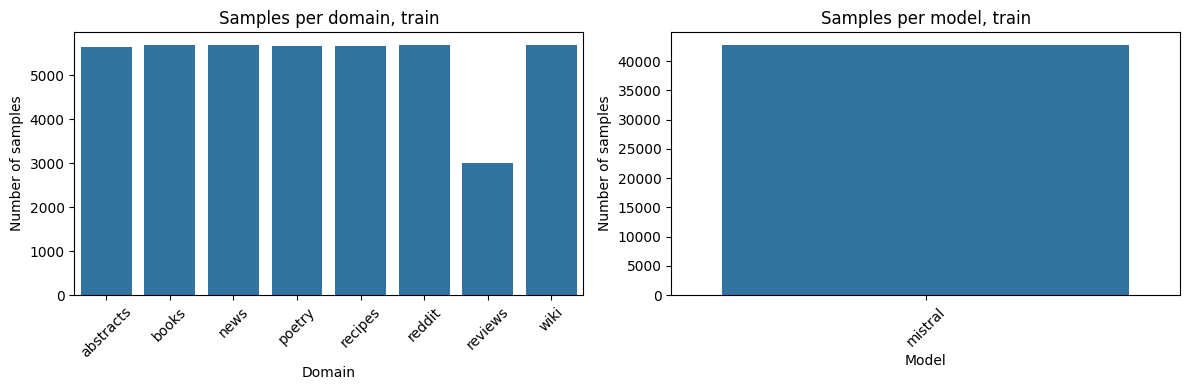

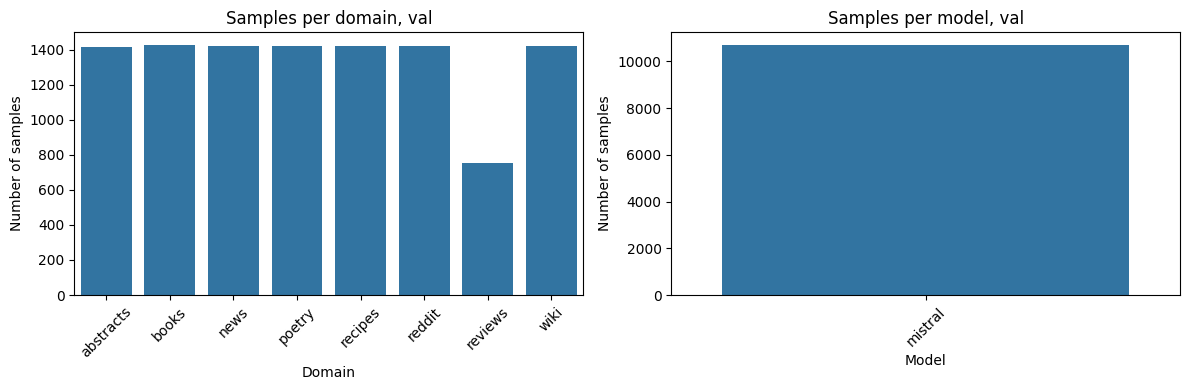

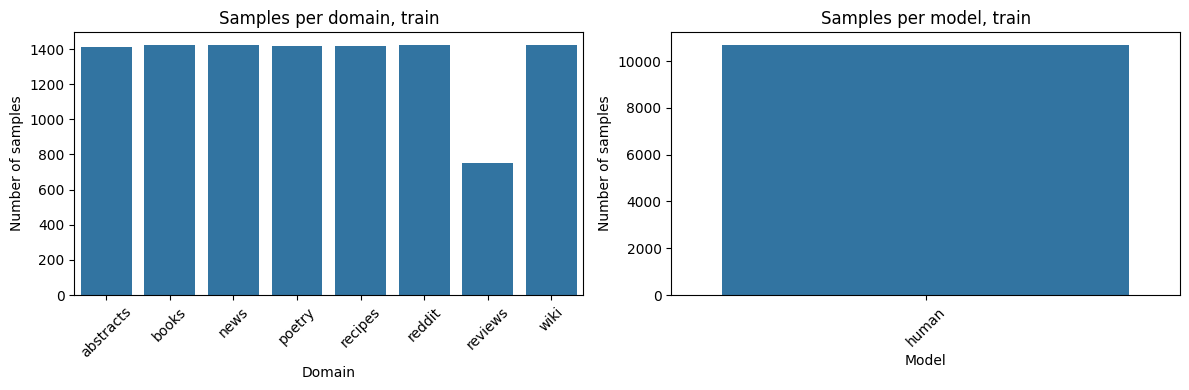

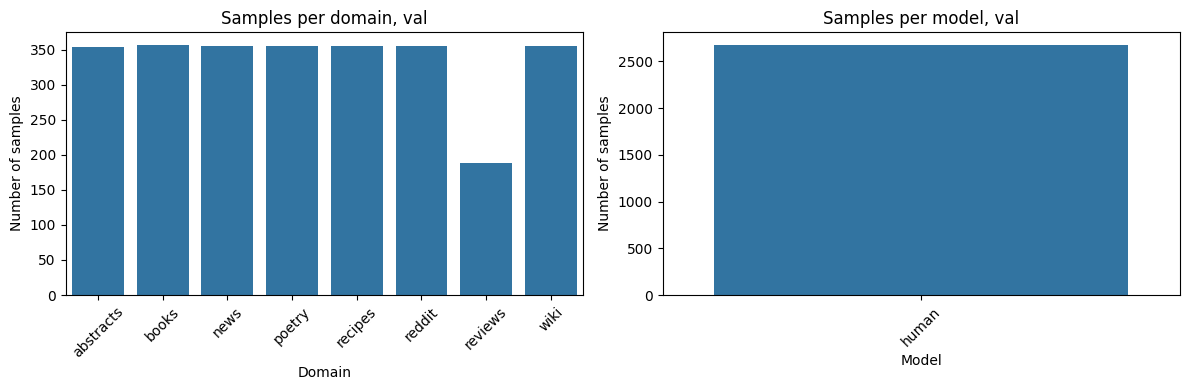

In [ ]:
plot_datasets(fake_train_val)
plot_datasets(real_train_val)

In [ ]:
fake_train_val.save_to_disk(f'{dir_path}fake_train_val')
real_train_val.save_to_disk(f'{dir_path}real_train_val')

In [ ]:
fake_train_val = load_from_disk(f'{dir_path}fake_train_val')
real_train_val = load_from_disk(f'{dir_path}real_train_val')

# **Вычисление активаций Train и стиринг векторов для каждого слоя LLM**

In [ ]:
def get_sample_activations(sample, layer_type=layer_type, mean_tokens=True):

    '''Функция для вычисления векторов активации для каждого слоя LLM'''

    with record_activations(LLM, layer_type=layer_type) as recorded_activations:
        inputs = tokenizer(sample,
                           return_tensors='pt',
                           max_length=max_seq_length,
                           truncation=True,
                           padding=False
                          ).to('cuda')

        with torch.no_grad():
            LLM.forward(**inputs)

        if mean_tokens:
            #На каждом слое векторы активации для всех токенов усредняем
            activations = torch.stack([layer_activations[0].mean(dim=1).flatten() for layer_activations in recorded_activations.values()]).cpu().numpy()
        else:
            activations = torch.stack([layer_activations[0] for layer_activations in recorded_activations.values()]).squeeze(1).cpu().numpy()

    return activations

def get_dataset_activations(dataset):
    return np.array([get_sample_activations(sample['generation']) for sample in tqdm(dataset)])

## **Вычисление активаций Train**

In [ ]:
real_train_activations = get_dataset_activations(real_train_val['train'])
np.save(f'{dir_path}real_train_activations.npy', real_train_activations)

In [ ]:
fake_train_activations = get_dataset_activations(fake_train_val['train'])
np.save(f'{dir_path}fake_train_activations.npy', fake_train_activations)

In [ ]:
real_train_activations = np.load(f'{dir_path}real_train_activations.npy')
fake_train_activations = np.load(f'{dir_path}fake_train_activations.npy')

# **Вычисление активаций Val**

In [ ]:
real_val_activations = get_dataset_activations(real_train_val['val'])
np.save(f'{dir_path}real_val_activations.npy', real_val_activations)

In [ ]:
fake_val_activations = get_dataset_activations(fake_train_val['val'])
np.save(f'{dir_path}fake_val_activations.npy', fake_val_activations)

In [ ]:
real_val_activations = np.load(f'{dir_path}real_val_activations.npy')
fake_val_activations = np.load(f'{dir_path}fake_val_activations.npy')

## **Вычисление стиринг векторов при помощи PCA для каждого слоя**

In [ ]:
# rng = np.random.default_rng(seed=42)
# differences = (rng.permutation(train_fake_activations, axis=0) - rng.permutation(train_real_activations, axis=0))

In [ ]:
differences = fake_train_activations - np.concatenate([real_train_activations,
                                                       real_train_activations,
                                                       real_train_activations,
                                                       real_train_activations])

In [ ]:
differences.shape

(40, 32, 4096)

In [ ]:
def get_steering_vectors_with_pca(differences, layer):
    pca = PCA(n_components=1, random_state=42)
    layer_pca = pca.fit_transform(differences[layer])
    return layer_pca

In [ ]:
steering_vectors_pca = np.array(
    [get_steering_vectors_with_pca(differences.transpose((1, 2, 0)), layer) for layer in tqdm(range(num_layers))]
    ).squeeze(-1)

  0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
steering_vectors_pca.shape

(32, 4096, 1)

In [ ]:
np.save(f'{dir_path}steering_vectors_pca.npy', steering_vectors_pca)

In [ ]:
steering_vectors_pca = np.load(f'{dir_path}steering_vectors_pca.npy')

## **Вычисление стиринг векторов при помощи Mean Difference для каждого слоя**

In [ ]:
steering_vectors_mean = np.mean(fake_train_activations, axis=0) - np.mean(real_train_activations, axis=0)

In [ ]:
steering_vectors_mean = steering_vectors_mean / np.linalg.norm(steering_vectors_mean, axis=-1, keepdims=True)

In [ ]:
np.save(f'{dir_path}steering_vectors_mean.npy', steering_vectors_mean)

In [ ]:
steering_vectors_mean = np.load(f'{dir_path}steering_vectors_mean.npy')

## **Вычисление стиринг векторов при помощи Logistic Regression для каждого слоя**

In [ ]:
def get_steering_vectors_with_logreg(fake_activations, real_activations, layer):

    fake_acts = fake_activations[layer]
    real_acts = real_activations[layer]

    mean_acts = np.stack([fake_acts, real_acts]).mean(axis=0)

    fake_acts_centered = fake_acts - mean_acts
    real_acts_centered = real_acts - mean_acts

    X = np.concatenate([fake_acts_centered, real_acts_centered], axis=0)
    y = np.concatenate([np.ones(fake_acts_centered.shape[0], dtype=np.int8),
                        np.zeros(real_acts_centered.shape[0], dtype=np.int8)])

    logreg = LogisticRegression(solver='liblinear', fit_intercept=False, random_state=42)

    layer_logreg = logreg.fit(X, y)

    logreg_coef = logreg.coef_
    normalized_logreg_coef = logreg_coef / np.linalg.norm(logreg_coef, axis=-1, keepdims=True)

    return normalized_logreg_coef.squeeze(0)

In [ ]:
fake_train_activations.transpose((1, 0, 2)).shape

(32, 40, 4096)

In [ ]:
real_train_activations.transpose((1, 0, 2)).shape

(32, 10, 4096)

In [ ]:
np.stack([fake_train_activations.transpose((1, 0, 2)),
          np.concatenate([real_train_activations,
                          real_train_activations,
                          real_train_activations,
                          real_train_activations]).transpose((1, 0, 2))]).mean(axis=0)

In [ ]:
steering_vectors_logreg = np.array(
    [get_steering_vectors_with_logreg(fake_train_activations.transpose((1, 0, 2)),
                                      np.concatenate([real_train_activations,
                                                      real_train_activations,
                                                      real_train_activations,
                                                      real_train_activations]).transpose((1, 0, 2)),
                                      layer
                                      ) for layer in tqdm(range(num_layers))])

In [ ]:
np.save(f'{dir_path}steering_vectors_logreg.npy', steering_vectors_logreg)

In [ ]:
steering_vectors_logreg = np.load(f'{dir_path}steering_vectors_logreg.npy')

# **Вычисление косинусных сходств активаций и стиринг-векторов для каждого слоя LLM**

In [ ]:
def get_dot_products(activations, steering_vectors):
    dot_products = np.sum(activations / np.linalg.norm(activations, axis=-1, keepdims=True) * steering_vectors, axis=2)
    return dot_products

##**Вычисление косинусных сходств для Train**

**PCA**

In [ ]:
real_train_dot_products_pca = get_dot_products(real_train_activations, steering_vectors_pca)

In [ ]:
fake_train_dot_products_pca = get_dot_products(fake_train_activations, steering_vectors_pca)

In [ ]:
X_train_pca = np.concatenate([real_train_dot_products_pca, fake_train_dot_products_pca], axis=0)

In [ ]:
np.save(f'{dir_path}X_train_pca.npy', X_train_pca)

In [ ]:
X_train_pca = np.load(f'{dir_path}X_train_pca.npy')

**Mean Difference**

In [ ]:
real_train_dot_products_mean = get_dot_products(real_train_activations, steering_vectors_mean)

In [ ]:
fake_train_dot_products_mean = get_dot_products(fake_train_activations, steering_vectors_mean)

In [ ]:
X_train_mean = np.concatenate([real_train_dot_products_mean, fake_train_dot_products_mean], axis=0)

In [ ]:
np.save(f'{dir_path}X_train_mean.npy', X_train_mean)

In [ ]:
X_train_mean = np.load(f'{dir_path}X_train_mean.npy')

**Logistic Regression**

In [ ]:
real_train_dot_products_logreg = get_dot_products(real_train_activations, steering_vectors_logreg)

In [ ]:
fake_train_dot_products_logreg = get_dot_products(fake_train_activations, steering_vectors_logreg)

In [ ]:
X_train_logreg = np.concatenate([real_train_dot_products_logreg, fake_train_dot_products_logreg], axis=0)

In [ ]:
np.save(f'{dir_path}X_train_logreg.npy', X_train_logreg)

In [ ]:
X_train_logreg = np.load(f'{dir_path}X_train_logreg.npy')

In [ ]:
y_train = np.concatenate([np.zeros(real_train_activations.shape[0], dtype=np.int8),
                          np.ones(fake_train_activations.shape[0], dtype=np.int8)], axis=0)

##**Вычисление косинусных сходств для Val**

**PCA**

In [ ]:
real_val_dot_products_pca = get_dot_products(real_val_activations, steering_vectors_pca)

In [ ]:
fake_val_dot_products_pca = get_dot_products(fake_val_activations, steering_vectors_pca)

In [ ]:
X_val_pca = np.concatenate([real_val_dot_products_pca, fake_val_dot_products_pca], axis=0)

In [ ]:
np.save(f'{dir_path}X_val_pca.npy', X_val_pca)

In [ ]:
X_val_pca = np.load(f'{dir_path}X_val_pca.npy')

**Mean Difference**

In [ ]:
real_val_dot_products_mean = get_dot_products(real_val_activations, steering_vectors_mean)

In [ ]:
fake_val_dot_products_mean = get_dot_products(fake_val_activations, steering_vectors_mean)

In [ ]:
X_val_mean = np.concatenate([real_val_dot_products_mean, fake_val_dot_products_mean], axis=0)

In [ ]:
np.save(f'{dir_path}X_val_mean.npy', X_val_mean)

In [ ]:
X_val_mean = np.load(f'{dir_path}X_val_mean.npy')

**Logistic Regression**

In [ ]:
real_val_dot_products_logreg = get_dot_products(real_val_activations, steering_vectors_logreg)

In [ ]:
fake_val_dot_products_logreg = get_dot_products(fake_val_activations, steering_vectors_logreg)

In [ ]:
X_val_logreg = np.concatenate([real_val_dot_products_logreg, fake_val_dot_products_logreg], axis=0)

In [ ]:
np.save(f'{dir_path}X_val_logreg.npy', X_val_logreg)

In [ ]:
X_val_logreg = np.load(f'{dir_path}X_val_logreg.npy')

In [ ]:
y_val = np.concatenate([np.zeros(real_val_activations.shape[0], dtype=np.int8),
                        np.ones(fake_val_activations.shape[0], dtype=np.int8)], axis=0)

# **Обучение и оценка качества логистической регрессии для детекции сгенерированных текстов**

In [ ]:
def train_and_evaluate_logistic_regression(X_y_Set,
                                           X_valid,
                                           y_valid,
                                           penalties=['l1', 'l2'],
                                           Cs=np.arange(0.1, 1.1, 0.1)
                                           ):

    '''Функция для тренировки и оценки качества логистический регрессии, обученной на массиве скалярных произведений'''

    metrics_dict = {}
    metrics_list = []

    for x_y_set in X_y_Set:
        X, y, Set = x_y_set

        if Set == 'Train':
            best_score = 0
            for penalty in penalties:
                for C in Cs:

                    model = LogisticRegression(solver='liblinear',
                                               max_iter=1000,
                                               penalty=penalty,
                                               C=C,
                                               random_state=42)
                    model.fit(X, y)

                    y_proba_valid = model.predict_proba(X_valid)[:, 1]
                    thresholds = np.linspace(0, 1, num=100, endpoint=False) #создается массив с значениями вероятностей
                    #для каждого порога вычисляется метрика f1
                    f1_scores = np.array([f1_score(y_valid, y_proba_valid>threshold, average='macro') for threshold in thresholds])
                    best_f1_score = np.max(f1_scores)
                    threshold = thresholds[np.argmax(f1_scores)] #определяется порог, соответствующий максимальному значению f1

                    if best_f1_score > best_score:
                        best_score = best_f1_score
                        best_threshold = threshold
                        best_model = model

        y_proba = best_model.predict_proba(X)[:, 1]

        roc_auc = roc_auc_score(y, y_proba)
        average_precision = average_precision_score(y, y_proba)
        f1 = f1_score(y, y_proba>best_threshold, average='macro')
        accuracy = accuracy_score(y, y_proba>best_threshold)

        metrics_set_for_dict = {
            f'AP, {Set}': average_precision,
            f'ROC AUC, {Set}': roc_auc,
            f'F1, {Set}': f1,
            f'Accuracy, {Set}': accuracy
                   }

        metrics_set_for_list = {
            f'Average precision': average_precision,
            f'ROC AUC': roc_auc,
            f'Macro F1': f1,
            f'Accuracy': accuracy,
                   }

        metrics_dict = metrics_dict | metrics_set_for_dict
        metrics_list.append(metrics_set_for_list)

    return best_model, metrics_list, metrics_dict

**Обучение модели на всех признаках**

**PCA**

In [ ]:
X_y_Set_zip_pca = zip(
    [X_train_pca, X_val_pca],
    [y_train, y_val],
    ['Train', 'Val']
)

In [ ]:
logistic_regression_pca, metrics_list_lr_pca, _ = train_and_evaluate_logistic_regression(X_y_Set=deepcopy(X_y_Set_zip_pca),
                                                                                         X_valid=X_val_pca,
                                                                                         y_valid=y_val
                                                                                         )

In [ ]:
logistic_regression_pca.get_params()['penalty']

In [ ]:
logistic_regression_pca.get_params()['C']

In [ ]:
metrics_df_lr_pca = pd.DataFrame(metrics_list_lr_pca,
                                 columns=['Average precision', 'ROC AUC', 'Macro F1', 'Accuracy'],
                                 index=['Train', 'Val']
                                )
metrics_df_lr_pca

**Mean difference**

In [ ]:
X_y_Set_zip_mean = zip(
    [X_train_mean, X_val_mean],
    [y_train, y_val],
    ['Train', 'Val']
)

In [ ]:
logistic_regression_mean, metrics_list_lr_mean, _ = train_and_evaluate_logistic_regression(X_y_Set=deepcopy(X_y_Set_zip_mean),
                                                                                           X_valid=X_val_mean,
                                                                                           y_valid=y_val
                                                                                           )

In [ ]:
logistic_regression_mean.get_params()['penalty']

In [ ]:
logistic_regression_mean.get_params()['C']

In [ ]:
metrics_df_lr_mean = pd.DataFrame(metrics_list_lr_mean,
                                  columns=['Average precision', 'ROC AUC', 'Macro F1', 'Accuracy'],
                                  index=['Train', 'Val']
                                  )
metrics_df_lr_mean

**Logistic Regression**

In [ ]:
X_y_Set_zip_logreg = zip(
    [X_train_logreg, X_val_logreg],
    [y_train, y_val],
    ['Train', 'Val']
)

In [ ]:
logistic_regression_logreg, metrics_list_lr_logreg, _ = train_and_evaluate_logistic_regression(X_y_Set=deepcopy(X_y_Set_zip_logreg),
                                                                                               X_valid=X_val_logreg,
                                                                                               y_valid=y_val
                                                                                               )

In [ ]:
logistic_regression_logreg.get_params()['penalty']

In [ ]:
logistic_regression_logreg.get_params()['C']

In [ ]:
metrics_df_lr_logreg = pd.DataFrame(metrics_list_lr_logreg,
                            columns=['Average precision', 'ROC AUC', 'Macro F1', 'Accuracy'],
                            index=['Train', 'Val']
                          )
metrics_df_lr_logreg

**Обучение модели на каждом слое**

In [ ]:
def get_metrics_per_layer(X_y_Set,
                          num_layers,
                          function,
                          X_valid,
                          y_valid,
                          penalties=['l1', 'l2'],
                          Cs=np.arange(0.1, 1.1, 0.1)
                          ):

    '''Функция для тренировки и оценки качества модели, обученной для каждого слоя отдельно'''

    metrics_per_layer = []

    for layer in tqdm(range(num_layers)):

        X_y_Set_layer = map(
            lambda x_y_set: (x_y_set[0][:, layer::num_layers], x_y_set[1], x_y_set[2]),
            deepcopy(X_y_Set)
        )

        X_valid_layer = X_valid[:, layer::num_layers]

        _, _, metrics_of_layer = function(X_y_Set_layer, X_valid_layer, y_valid, penalties, Cs)

        metrics_per_layer.append(metrics_of_layer)

    metrics_per_layer = pd.DataFrame(metrics_per_layer)

    return metrics_per_layer

In [ ]:
def plot_metrics_per_layer(data,
                           model,
                           Sets,
                           aggregator
                          ):
    '''Функция для визуализации метрик качества модели для каждого слоя отдельно'''

    for i, Set in enumerate(Sets):
        plt.figure(figsize=(14, 7))
        sns.lineplot(data=data[[f'Accuracy, {Set}', f'AP, {Set}', f'ROC AUC, {Set}', f'F1, {Set}']],
                     markers=True, dashes=False)
        plt.xlabel('Layer')
        plt.title(f'Metrics of {model} by layer on {Set}, aggregator {aggregator}')
        plt.tight_layout()
        plt.show()

**PCA**

In [ ]:
metrics_per_layer_lr_pca = get_metrics_per_layer(X_y_Set=deepcopy(X_y_Set_zip_pca),
                                                 num_layers=num_layers,
                                                 function=train_and_evaluate_logistic_regression,
                                                 X_valid=X_val_pca,
                                                 y_valid=y_val
                                                 )

In [ ]:
metrics_per_layer_lr_pca.style.highlight_max(axis=0, color='green')

In [ ]:
plot_metrics_per_layer(data=metrics_per_layer_lr_pca,
                       model='logistic regression',
                       Sets=['Train', 'Val'],
                       aggregator='PCA')

**Mean Difference**

In [ ]:
metrics_per_layer_lr_mean = get_metrics_per_layer(X_y_Set=deepcopy(X_y_Set_zip_mean),
                                                  num_layers=num_layers,
                                                  function=train_and_evaluate_logistic_regression,
                                                  X_valid=X_val_mean,
                                                  y_valid=y_val
                                                  )

In [ ]:
metrics_per_layer_lr_mean.style.highlight_max(axis=0, color='green')

In [ ]:
plot_metrics_per_layer(data=metrics_per_layer_lr_mean,
                       model='logistic regression',
                       Sets=['Train', 'Val'],
                       aggregator='Mean Difference')

**Logistic Regression**

In [ ]:
metrics_per_layer_lr_logreg = get_metrics_per_layer(X_y_Set=deepcopy(X_y_Set_zip_logreg),
                                                    num_layers=num_layers,
                                                    function=train_and_evaluate_logistic_regression,
                                                    X_valid=X_val_logreg,
                                                    y_valid=y_val
                                                    )

In [ ]:
metrics_per_layer_lr_logreg.style.highlight_max(axis=0, color='green')

In [ ]:
plot_metrics_per_layer(data=metrics_per_layer_lr_logreg,
                       model='logistic regression',
                       Sets=['Train', 'Val'],
                       aggregator='Logistic Regression')